<a href="https://colab.research.google.com/github/trishausirikapalli-del/growfinix/blob/main/task4_Movie_review_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


                                              review sentiment
0  plot : two teen couples go to a church party ,...       neg
1  the happy bastard's quick movie review \ndamn ...       neg
2  it is movies like these that make a jaded movi...       neg
3   " quest for camelot " is warner bros . ' firs...       neg
4  synopsis : a mentally unstable man undergoing ...       neg

Cleaned Text Sample:

                                              review  \
0  plot : two teen couples go to a church party ,...   
1  the happy bastard's quick movie review \ndamn ...   
2  it is movies like these that make a jaded movi...   
3   " quest for camelot " is warner bros . ' firs...   
4  synopsis : a mentally unstable man undergoing ...   

                                        clean_review  
0  plot two teen couples go church party drink dr...  
1  happy bastards quick movie review damn yk bug ...  
2  movies like make jaded movie viewer thankful i...  
3  quest camelot warner bros first feature

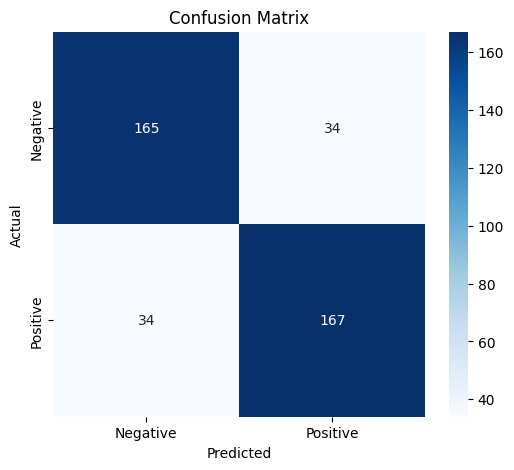

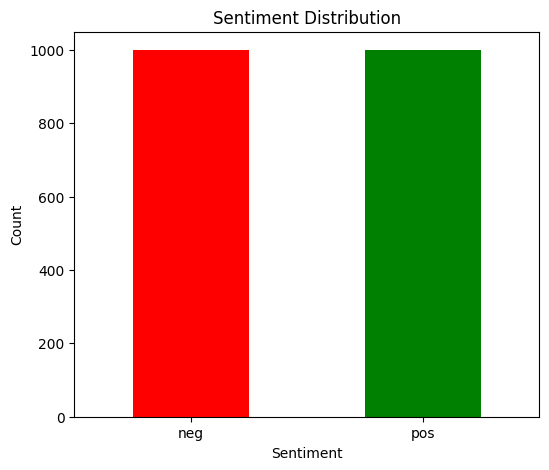

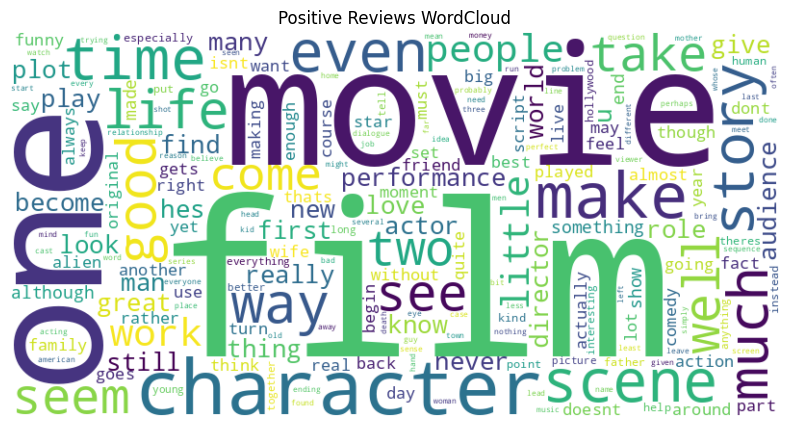

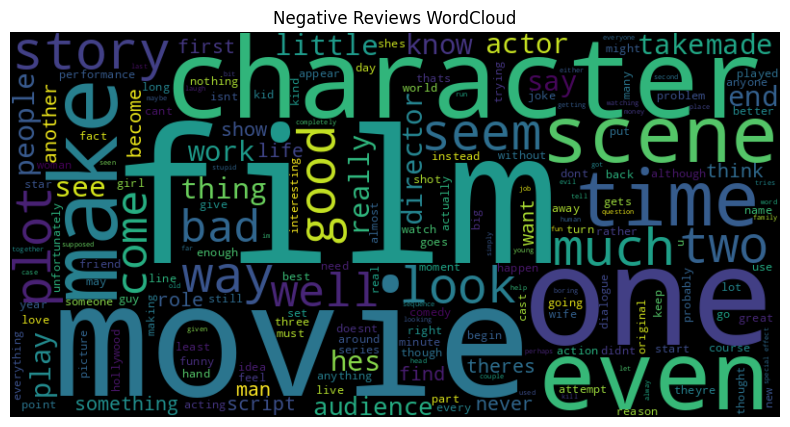


Custom Predictions:

Review: This movie was absolutely fantastic with great acting
Predicted Sentiment: pos

Review: Worst movie ever, complete waste of time
Predicted Sentiment: neg

Movie Review Sentiment Analysis Completed
Model Used: Logistic Regression
Feature Extraction: TF-IDF


In [1]:
# ================================
# Movie Review Sentiment Analysis
# ================================

# Install required library
!pip install wordcloud

# ================================
# 1. Import Libraries
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import movie_reviews
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from wordcloud import WordCloud

# ================================
# 2. Download NLTK Dataset
# ================================

nltk.download('movie_reviews')
nltk.download('stopwords')

# ================================
# 3. Load Dataset
# ================================

documents = []

for category in movie_reviews.categories():
    for fileid in movie_reviews.fileids(category):
        review = movie_reviews.raw(fileid)
        documents.append((review, category))

# Create DataFrame
df = pd.DataFrame(documents, columns=['review', 'sentiment'])

print(df.head())

# ================================
# 4. Text Preprocessing
# ================================

stop_words = set(stopwords.words('english'))

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

# Apply cleaning
df['clean_review'] = df['review'].apply(clean_text)

print("\nCleaned Text Sample:\n")
print(df[['review', 'clean_review']].head())

# ================================
# 5. Convert Text to Numerical Data
# ================================

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_review']).toarray()
y = df['sentiment']

# ================================
# 6. Split Dataset
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ================================
# 7. Train Logistic Regression Model
# ================================

model = LogisticRegression()

model.fit(X_train, y_train)

# ================================
# 8. Predictions
# ================================

y_pred = model.predict(X_test)

# ================================
# 9. Accuracy Evaluation
# ================================

accuracy = accuracy_score(y_test, y_pred)

print("\n==============================")
print("Model Accuracy:", accuracy)
print("==============================")

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ================================
# 10. Confusion Matrix
# ================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ================================
# 11. Sentiment Distribution
# ================================

sentiment_counts = df['sentiment'].value_counts()

plt.figure(figsize=(6,5))
sentiment_counts.plot(kind='bar', color=['red', 'green'])

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

# ================================
# 12. WordCloud Visualization
# ================================

positive_reviews = " ".join(
    df[df['sentiment'] == 'pos']['clean_review']
)

negative_reviews = " ".join(
    df[df['sentiment'] == 'neg']['clean_review']
)

# Positive WordCloud
positive_wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_reviews)

plt.figure(figsize=(10,5))
plt.imshow(positive_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Positive Reviews WordCloud")
plt.show()

# Negative WordCloud
negative_wc = WordCloud(
    width=800,
    height=400,
    background_color='black'
).generate(negative_reviews)

plt.figure(figsize=(10,5))
plt.imshow(negative_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Negative Reviews WordCloud")
plt.show()

# ================================
# 13. Custom Review Prediction
# ================================

def predict_sentiment(review):

    cleaned = clean_text(review)

    vectorized = tfidf.transform([cleaned]).toarray()

    prediction = model.predict(vectorized)[0]

    return prediction

# Example Reviews
review1 = "This movie was absolutely fantastic with great acting"
review2 = "Worst movie ever, complete waste of time"

print("\nCustom Predictions:\n")

print("Review:", review1)
print("Predicted Sentiment:", predict_sentiment(review1))

print()

print("Review:", review2)
print("Predicted Sentiment:", predict_sentiment(review2))

# ================================
# 14. Final Conclusion
# ================================

print("\n========================================")
print("Movie Review Sentiment Analysis Completed")
print("Model Used: Logistic Regression")
print("Feature Extraction: TF-IDF")
print("========================================")